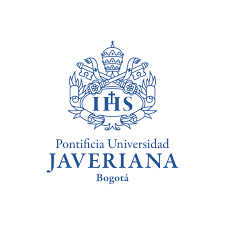
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Juan Martin Trejos Vanegas

Fecha de Inicio: 02/04/2026

Fecha actual: 27/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

In [2]:
import os

import sys

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *


In [3]:
import sys
import os

print("Python driver:")
print(sys.version)

print("Ruta driver:")
print(sys.executable)

print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON"))
print("PYSPARK_DRIVER_PYTHON:", os.environ.get("PYSPARK_DRIVER_PYTHON"))

Python driver:
3.9.25 (main, Nov  7 2025, 18:07:57) 
[GCC 11.4.0]
Ruta driver:
/usr/bin/python3.9
PYSPARK_PYTHON: /usr/bin/python3.9
PYSPARK_DRIVER_PYTHON: None


### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("Calidad_Agua_Corredor")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkCorredor

In [4]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Trejos")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS  = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkS

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 23:34:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

In [5]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)


/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

In [6]:
import sys
print(sys.version)

3.9.25 (main, Nov  7 2025, 18:07:57) 
[GCC 11.4.0]


## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [7]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

In [8]:
for valor in df00.columns:
     df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+



+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|
+-------+-----------------+

+-------+-------------------+
|summary|NITRATE_N_NITRITE_N|
+-------+-------------------+
|  count|                534|
|   mean| 1.3785714285714301|
| stddev|  2.803947753154703|
|    min|                  0|
|    max|    

## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

In [9]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+





* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* #Se crea una vista para ser usada en las visualizaciones
* df00.createOrReplaceTempView("df00_sql")
* df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

In [10]:
df00.createOrReplaceTempView("df00_sql")

In [11]:
df01 = sparkS.sql('''
    Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

* #Se verifica la Cantidad de Valores Nulos o Imposibles
* df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

In [12]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de datos**

* df00.dtypes
* ##Se procede a cambiar los tipos de datos
* df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
* df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
* df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
* df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
* df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
* df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
* df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
* df00.dtypes


* ##Se elimina la columna TOTAL_COLIFORM
* df01 = df00.drop('TOTAL_COLIFORM')
* df01.columns

In [13]:
df00.dtypes

##Se procede a cambiar los tipos de datos

df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))

df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))

df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))

df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))

df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))

df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))

df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

df00.dtypes

##Se elimina la columna TOTAL_COLIFORM

df01 = df00.drop('TOTAL_COLIFORM')

df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

- df01.createOrReplaceTempView("df01_sql")

- ###Se crea una consulta por cada parámetro DO
- do_parametro = sparkS.sql("Select DO from df01_sql")
- ##Se hace una consulta para crear el vector de la tabla por cada parámetro
- do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

In [14]:
###Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

df01.createOrReplaceTempView("df01_sql")

In [15]:
do_parametro = sparkS.sql("Select DO from df01_sql")

In [16]:
ph_parametro=sparkS.sql("Select pH from df01_sql")

In [17]:
bod_parametro=sparkS.sql("Select BOD from df01_sql")

In [18]:
nitrato_parametro=sparkS.sql("Select NITRATE_N_NITRITE_N from df01_sql")

In [19]:
FC_parametro=sparkS.sql("Select FECAL_COLIFORM from df01_sql")

In [20]:
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()


In [21]:
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()


In [22]:
bod_parametro = bod_parametro.rdd.map(lambda fila: fila.BOD).collect()


In [23]:
nitrato_parametro = nitrato_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()


In [24]:
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()


* ###Grafica Los parámetros para conocer sus características: DO y PH

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), ph_parametro, label='pH')
* fig.suptitle('Parámetro DO y pH de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

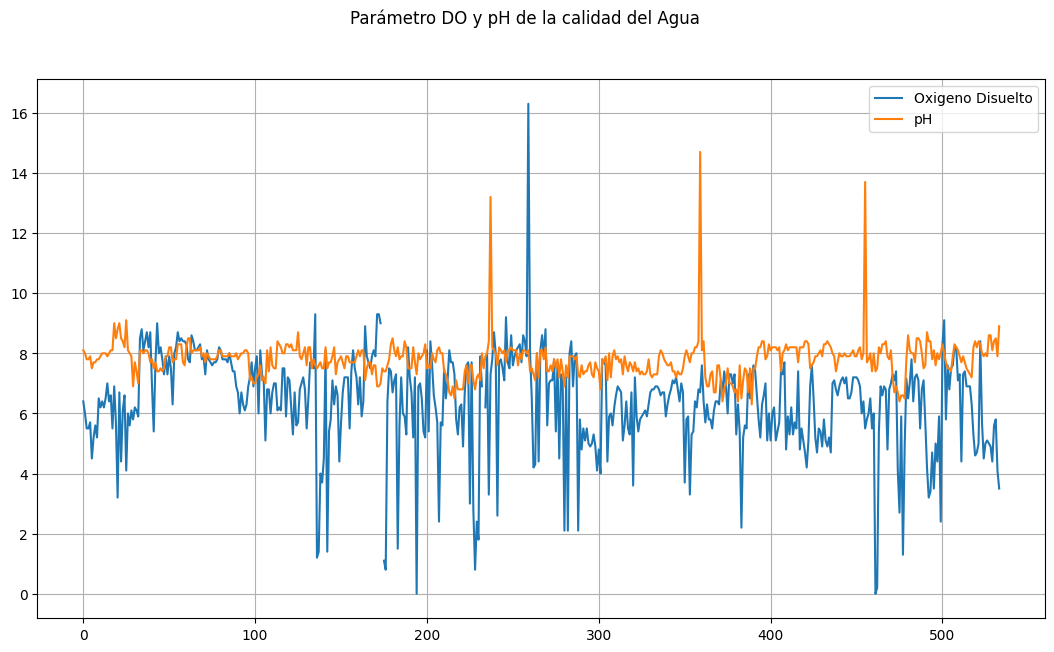

In [25]:


df01.createOrReplaceTempView("df01_sql")

tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0, tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0, tam), ph_parametro, label='pH')

fig.suptitle('Parámetro DO y pH de la calidad del Agua')

legend = ax1.legend()

plt.grid()
plt.show()

###La gráfica muestra que el pH presenta un comportamiento relativamente estable, concentrándose principalmente entre valores cercanos a 7 y 8.5. En contraste, el oxígeno disuelto muestra una mayor variabilidad, con caídas importantes cercanas a cero y algunos picos elevados. Esto indica que la oxigenación del agua cambia considerablemente entre las muestras, mientras que el pH se mantiene más constante. Los valores extremos observados en ambas variables podrían considerarse posibles atípicos y deberían revisarse antes de continuar con el análisis del índice de calidad del agua.


* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
* ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
* fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
* legend=ax1.legend()
* plt.grid()
* plt.show()

In [28]:
BOD_parametro = [fila["BOD"] for fila in sparkS.sql("SELECT BOD FROM df01_sql").collect()]

NN_parametro = [
    fila["NITRATE_N_NITRITE_N"] 
    for fila in sparkS.sql("SELECT NITRATE_N_NITRITE_N FROM df01_sql").collect()
]

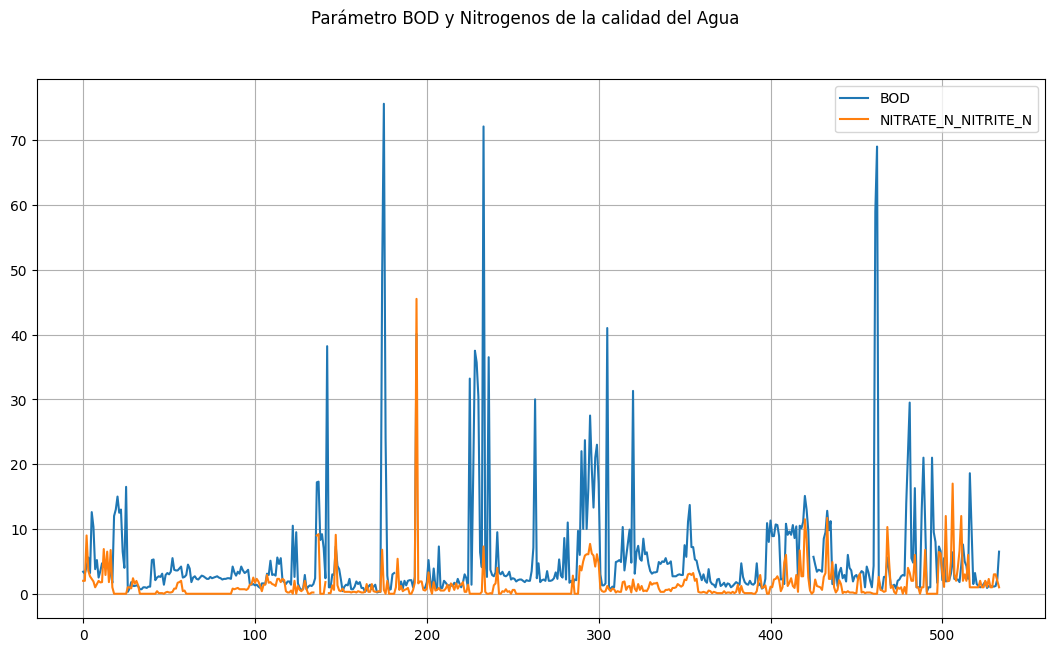

In [29]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), BOD_parametro, label='BOD')

ax1.plot(range(0,tam), nitrato_parametro, label='NITRATE_N_NITRITE_N')

fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')

legend=ax1.legend()

plt.grid()

plt.show()

###La gráfica muestra que el BOD presenta una alta variabilidad entre las observaciones, con varios picos elevados que pueden indicar presencia importante de materia orgánica en ciertas muestras de agua. En contraste, los valores de NITRATE_N_NITRITE_N se mantienen generalmente bajos, aunque también aparecen algunos picos aislados que podrían estar asociados con contaminación por fertilizantes, aguas residuales o escorrentía agrícola. En general, la presencia de valores extremos en ambos parámetros sugiere que existen registros puntuales con posibles problemas de contaminación, por lo que estos datos deben ser revisados con mayor detalle antes de calcular o interpretar el índice de calidad del agua.

* ###Grafica Los parámetros para conocer sus características: FC y Conductividad

* tam = len(do_parametro)
* fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
* ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
* ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
* fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
* legend=ax1.legend()
* plt.xlabel("Hola que tal estas")
* plt.grid()
* plt.show()

In [34]:
COND_parametro = [
    fila["CONDUCTIVITY"] 
    for fila in sparkS.sql("SELECT CONDUCTIVITY FROM df01_sql").collect()
]
FC_parametro = [
    fila["FECAL_COLIFORM"] 
    for fila in sparkS.sql("SELECT FECAL_COLIFORM FROM df01_sql").collect()
]

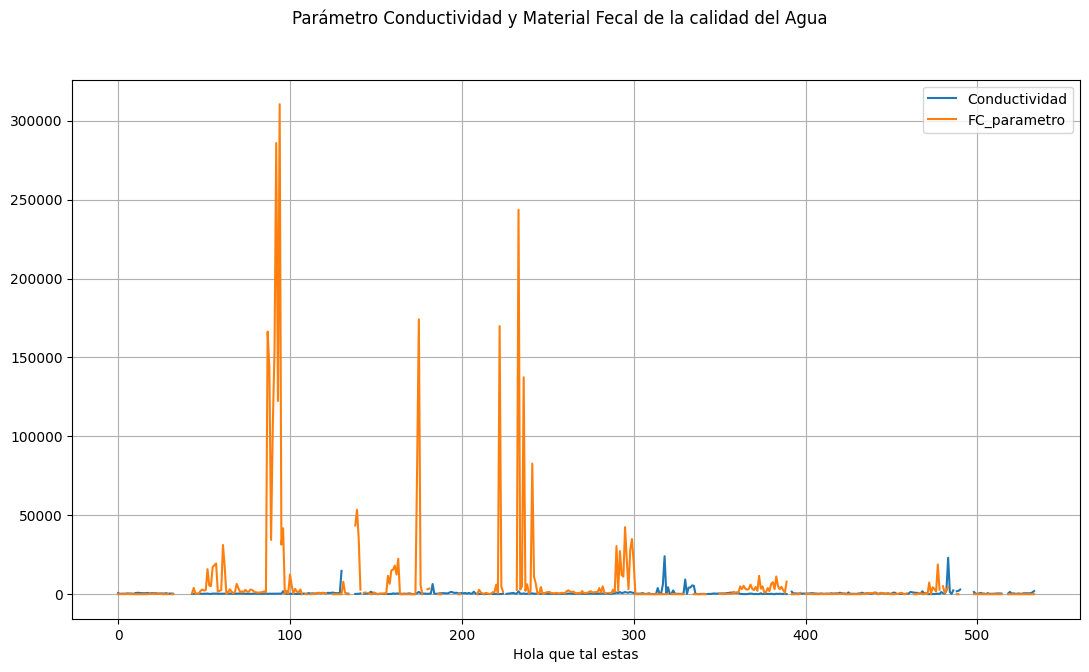

In [35]:
###Grafica Los parámetros para conocer sus características: FC y Conductividad

tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), COND_parametro, label='Conductividad')

ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')

legend=ax1.legend()

plt.xlabel("Hola que tal estas")

plt.grid()

plt.show()

En la gráfica se comparan los valores de conductividad y coliformes fecales en las diferentes observaciones del conjunto de datos. Se observa que la variable FC_parametro presenta picos extremadamente altos, algunos superiores a 300.000, mientras que la conductividad se mantiene en una escala mucho menor. Esto hace que visualmente la conductividad quede casi “aplastada” en la parte inferior de la gráfica.

Los picos altos de coliformes fecales son muy importantes, porque pueden indicar presencia de contaminación microbiológica asociada a materia fecal, aguas residuales o descargas sin tratamiento adecuado. A diferencia de otros parámetros físico-químicos, este indicador tiene una relación directa con posibles riesgos sanitarios, por lo que los registros con valores extremos deberían revisarse cuidadosamente.

La conductividad, aunque se observa menos por la escala, también presenta algunos aumentos puntuales. Esta variable se relaciona con la cantidad de sales, minerales o sólidos disueltos en el agua. Valores elevados pueden indicar presencia de descargas industriales, escorrentía o alta concentración de iones disueltos.

* #Función definida por el usuario para definir el rango de calidad de agua según el pH
* #Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

* df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

In [36]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

 when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

 when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

 when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según DO
* df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
  *                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
  *                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
  *                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

In [45]:
f02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
               when((df01.DO>=5.1) & (df01.DO<6.0), 80).
               when((df01.DO>=4.1) & (df01.DO<5.0), 60).
               when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según COND
* df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
  *          when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
  *          when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
  *          when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

In [46]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
     when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
     when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
     when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD
* df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
  *                     when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
  *                     when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
  *                     when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

In [47]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))


* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura
* df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
  *                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
  *                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
  *                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

In [48]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))


* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

In [49]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).

               when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
               when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
               when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

* #A continuación se hace una inspección en general del df02
     * df02.show(10)
* ##Nombre de Columnas
     * df02.columns

In [42]:
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|          90.0| 100|     0|   80

In [50]:
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

In [52]:
df02 = df02.withColumn(
    "qrDO",
    F.when(F.col("DO") >= 6, 100)
     .when((F.col("DO") >= 5) & (F.col("DO") < 6), 80)
     .when((F.col("DO") >= 4) & (F.col("DO") < 5), 60)
     .when((F.col("DO") >= 3) & (F.col("DO") < 4), 40)
     .otherwise(20)
)

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

* ###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
    * df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
    * df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
    * df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
    * df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
    * df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
    * df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

* df03.show(10)

* df03.columns

In [53]:
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

In [54]:
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [55]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'qrDO',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

In [56]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))

In [57]:
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

* df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   * .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   * .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   * .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   * .otherwise('Inadecuada')
                      )
* df05.show(10)

In [59]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
                       .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
.when((df04.WQI>=50) & (df04.WQI<75),'Baja')
.when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
.otherwise('Inadecuada') )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa

* colEstado = 'STATE'
* valNomnbres = df05.select(colEstado).distinct().collect()
* valNomnbres = [v[colEstado] for v in valNomnbres]

* print(valNomnbres)


In [60]:
colEstado = 'STATE'

valNomnbres = df05.select(colEstado).distinct().collect()

valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

- import geopandas as gpd

- rutaMapas = "/home/sistemas/Documents/ProcDatos/TallerWaterCorredor/Indian_States.shp"
- ## Se carga un objeto dataframe de los datos comprimidos de los mapas
- gpd01 = gpd.read_file(rutaMapas)

- ## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


- #Se visualizan los nombres de la columna de los estados "st_nm"
- gpd01["st_nm"].unique()

- ### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
- ### con los nombres de los estados del dataframe de datos inicial

- gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
  -                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
  -                    'Daman & Diu': 'Daman Diu', 
  -                     'Jammu & Kashmir': 'Jammu Kashmir',
  -                     'NCT of Delhi' : 'Delhi'
                      })
- gpd02["st_nm"].unique()

In [74]:
import geopandas as gpd
rutaMapas="/home/estudiante/Documents/parcial2/Indian_States.shp"

In [76]:
gpd01 = gpd.read_file(rutaMapas)
print(type(gpd01))
gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [79]:
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                      'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                     'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                      'NCT of Delhi' : 'Delhi'
                      })

In [80]:
gpd01["st_nm"].unique()

array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [81]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrCOND|qrBOD|qrNN|qrFecal|qrDO| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+------+-----+----+-------+----+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100|     0|   80| 100|    100| 100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100|    40|   80| 100|     60| 100|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [82]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

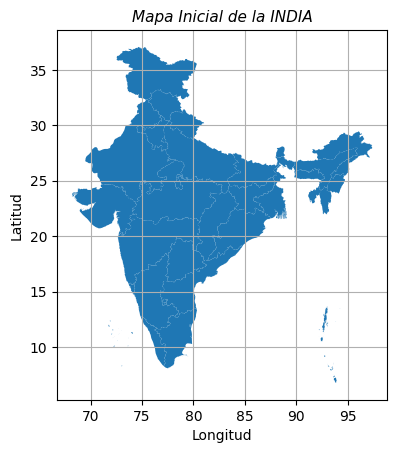

In [83]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [84]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 KB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.0 MB/s eta 0:00:0000:01


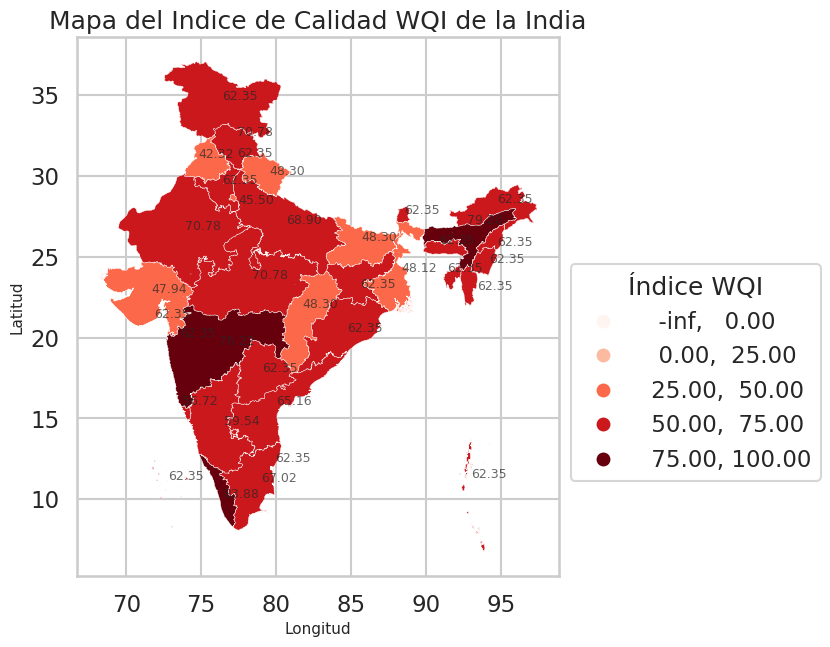

In [85]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

En el mapa se representa el Índice de Calidad del Agua, WQI, para diferentes estados de la India. Este índice permite resumir varios parámetros de calidad del agua en un solo valor, teniendo en cuenta variables como pH, oxígeno disuelto, conductividad, BOD, nitratos/nitritos y coliformes fecales.
Según la escala utilizada en el cuaderno, los valores más bajos de WQI indican mejor calidad del agua. Por ejemplo, un valor menor a 25 se asocia con agua potable o de mejor calidad. Por el contrario, a medida que el WQI aumenta, la calidad del agua tiende a disminuir. Por eso, los estados que aparecen con valores más altos no deben interpretarse como zonas con mejor calidad, sino como regiones donde el agua presenta mayor afectación.
En el mapa se observa que una gran parte de los estados tiene valores entre 50 y 75, lo cual indica una calidad del agua intermedia o deficiente. También se identifican algunos estados con valores cercanos o superiores a 75, representados con tonos más oscuros, lo que puede indicar una condición más crítica en comparación con los demás estados. Estas zonas podrían estar siendo afectadas por mayores concentraciones de contaminantes, especialmente parámetros como coliformes fecales, BOD o conductividad.
Por otra parte, los estados con valores entre 25 y 50 presentan una mejor condición relativa frente a los estados con WQI más alto, aunque no necesariamente entran en la categoría de agua potable. En el mapa no se observan muchas zonas con valores menores a 25, por lo que se puede decir que, de acuerdo con este análisis, pocas regiones alcanzan la categoría de mejor calidad del agua.
También es importante mencionar que algunos valores se repiten en varios estados, como ocurre con valores cercanos a 62.35. Esto puede deberse a que en algunos estados no había suficientes registros o a que se aplicaron procesos de agrupamiento, promedio o imputación de datos. Por esta razón, el mapa debe interpretarse como una aproximación general de la calidad del agua y no como una medición exacta para cada región.
En conclusión, el mapa permite identificar de forma visual qué zonas presentan mejores o peores condiciones de calidad del agua. La mayoría de los estados analizados se encuentran en rangos medios o altos de WQI, lo cual sugiere que existen problemas de calidad del agua en varias regiones de la India. Este resultado muestra la importancia de analizar con más detalle los estados con valores elevados para identificar qué parámetros están afectando más el índice final.

### **Histograma de WQI por Estado**

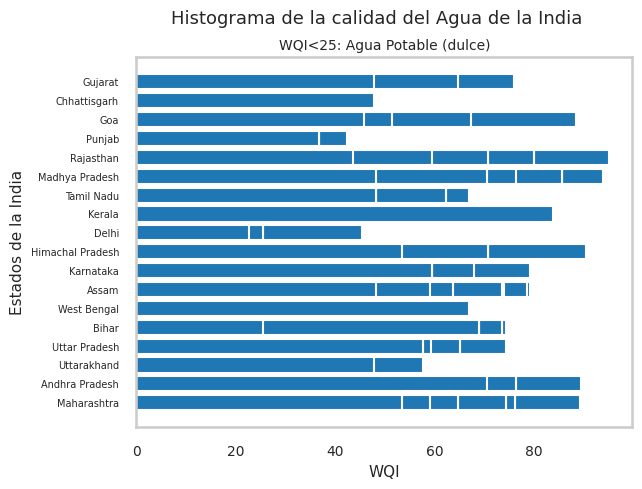

In [86]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

###Análisis del histograma del índice WQI###
En esta gráfica se muestra el Índice de Calidad del Agua WQI para diferentes estados de la India. Aunque el título dice “histograma”, realmente se puede interpretar más como un gráfico de barras horizontales, porque compara el valor del WQI entre varios estados.
Según la clasificación usada en el cuaderno, un valor de WQI menor a 25 representa agua potable o de mejor calidad. Por eso, en este análisis los valores bajos son mejores, mientras que los valores altos indican una peor calidad del agua.
Al observar la gráfica, se nota que la mayoría de los estados tienen valores de WQI superiores a 50, lo que indica que gran parte de las muestras no se encuentran dentro del rango considerado como agua potable. Estados como Rajasthan, Madhya Pradesh, Himachal Pradesh, Goa, Andhra Pradesh y Maharashtra presentan valores bastante altos, cercanos o superiores a 80 en algunos casos. Esto puede sugerir que en esas regiones hay mayor afectación en la calidad del agua.
También se observan estados con valores más bajos, como Punjab, Delhi, Chhattisgarh y Uttarakhand, que presentan una mejor condición relativa frente a los demás. Sin embargo, aun estos estados parecen estar por encima del rango menor a 25, por lo que no necesariamente se pueden clasificar como agua potable según la escala del cuaderno.
Una parte importante de esta gráfica es que permite comparar fácilmente qué estados tienen mayor o menor índice WQI. Los estados con barras más largas son los que presentan una calidad del agua más afectada, mientras que las barras más cortas representan mejores condiciones relativas.
En conclusión, la gráfica muestra que la mayoría de estados analizados presentan valores de WQI medios o altos, lo cual indica que la calidad del agua no es óptima en gran parte de las regiones evaluadas. Esto refuerza la necesidad de revisar con más detalle los parámetros que están influyendo en el índice, especialmente coliformes fecales, BOD, conductividad y oxígeno disuelto.

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [87]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'qrDO',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [88]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [90]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [91]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


Aunque la cantidad de datos no es muy grande para un modelo de red neuronal, la división permite realizar una primera aproximación al problema de predicción del WQI. 
Por esta razón, es importante complementar el análisis con métricas de evaluación como MAE, RMSE y R², además de comparar gráficamente los valores reales y predichos.

In [92]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-04-27 00:04:15.557028: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 00:04:15.655559: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 00:04:18.141674: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [93]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 00:04:26.995893: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [94]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [95]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

En esta sección se define la arquitectura del modelo de red neuronal usando Keras. El modelo recibe 6 variables de entrada, correspondientes a los rangos de calidad de los parámetros evaluados, y genera una única salida que corresponde al valor predicho del WQI. La red está compuesta por tres capas ocultas densas de 350 neuronas cada una, con función de activación ReLU, y una capa de salida lineal, adecuada para un problema de predicción numérica.

El resumen del modelo muestra un total de 248.501 parámetros entrenables. Esto indica que la red tiene una alta capacidad de aprendizaje; sin embargo, también implica un posible riesgo de sobreajuste, ya que el conjunto de entrenamiento contiene 427 registros. Por esta razón, el desempeño del modelo debe analizarse no solo con los datos de entrenamiento, sino principalmente con los datos de prueba. Además, es recomendable revisar métricas como el error cuadrático medio, MAE, RMSE y R² para determinar si el modelo realmente generaliza bien.

In [96]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1629.2407 - mse: 1629.2407
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 106.6661 - mse: 106.6661
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 68.9200 - mse: 68.9200  
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 40.5993 - mse: 40.5993
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.8904 - mse: 17.8904
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.3067 - mse: 8.3067  
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.0146 - mse: 5.0146
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.6498 - mse: 2.6498
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.3110 - mse: 1.3110
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7646 - mse: 0.7646
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3318 - mse: 0.3318
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2353 - mse: 0.2353
Epoch 13/200
6/6 ━━━━━━━━━━━━

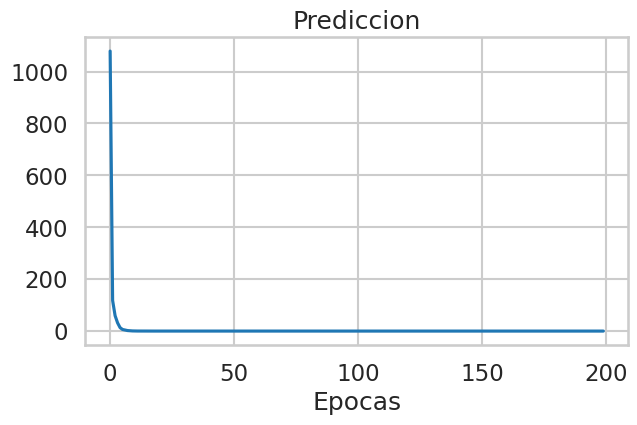

In [101]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Prediccion")
plt.xlabel("Epocas")
plt.show()

La gráfica muestra la evolución de la pérdida del modelo durante las épocas de entrenamiento. Se observa que al inicio el error es alto, pero disminuye rápidamente en las primeras iteraciones, lo cual indica que la red neuronal está aprendiendo la relación entre las variables de entrada y el índice WQI. Luego de pocas épocas, la curva se estabiliza cerca de cero, mostrando que el modelo logra ajustarse a los datos de entrenamiento. Sin embargo, esta gráfica por sí sola no permite concluir que el modelo predice correctamente datos nuevos, ya que solo representa el comportamiento sobre el conjunto de entrenamiento. Por esta razón, es necesario complementar el análisis con la evaluación sobre los datos de prueba y con métricas como MSE, MAE o R².

In [98]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


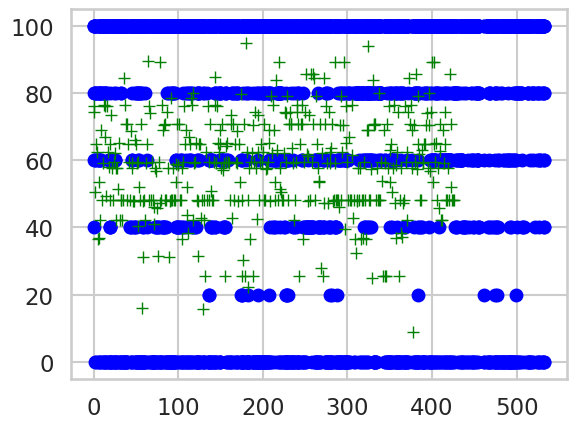

In [99]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()

En la gráfica se presentan los datos de entrenamiento junto con las predicciones generadas por el modelo. Los puntos azules corresponden a los rangos de calidad usados como entrada, los cuales se agrupan en valores discretos como 0, 20, 40, 60, 80 y 100. Las cruces verdes representan las predicciones del WQI realizadas por la red neuronal, las cuales se concentran principalmente entre valores de 40 y 80. Esto indica que el modelo está generando valores dentro del rango esperado del índice y que logra producir una salida continua a partir de las variables de entrada. Aunque la gráfica no permite medir con exactitud el error del modelo, sí muestra que las predicciones siguen una distribución coherente con los datos utilizados durante el entrenamiento.

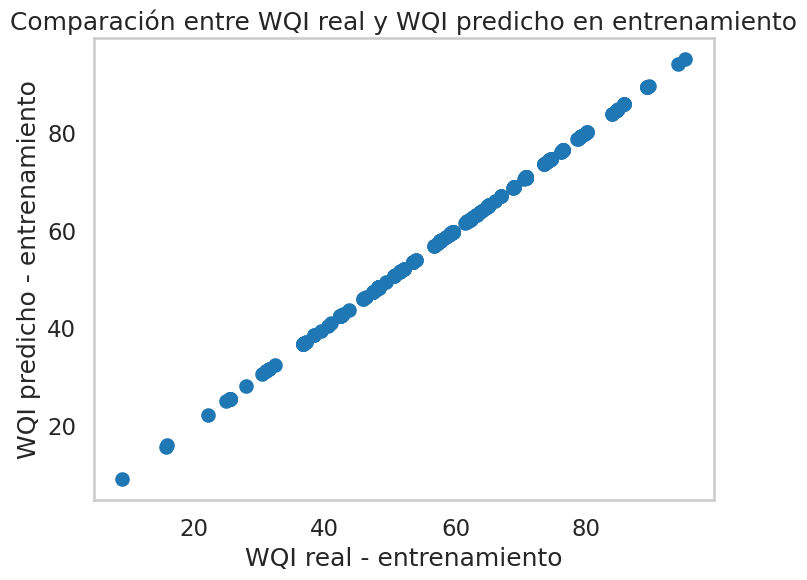

In [102]:
plt.figure(figsize=(8,6))
plt.scatter(predTrain, predModelo01_Train)
plt.xlabel("WQI real - entrenamiento")
plt.ylabel("WQI predicho - entrenamiento")
plt.title("Comparación entre WQI real y WQI predicho en entrenamiento")
plt.grid()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


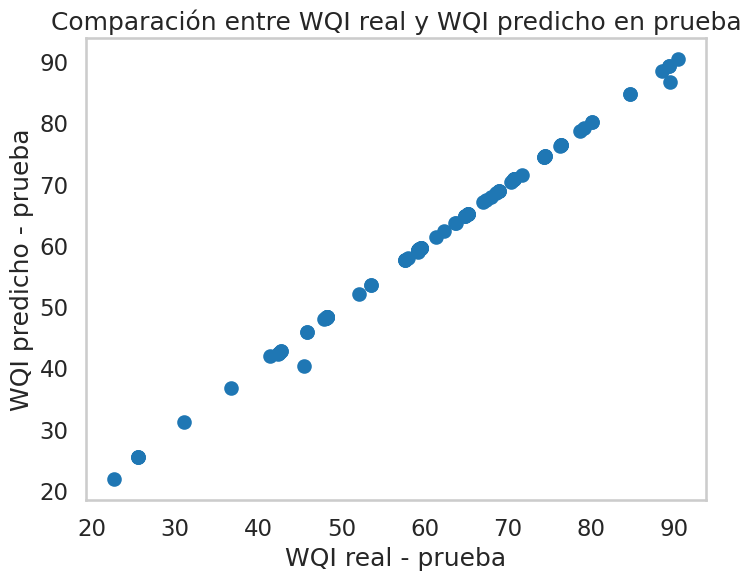

In [103]:
predModelo01_Test = modelo01.predict(dataTest)

plt.figure(figsize=(8,6))
plt.scatter(predTest, predModelo01_Test)
plt.xlabel("WQI real - prueba")
plt.ylabel("WQI predicho - prueba")
plt.title("Comparación entre WQI real y WQI predicho en prueba")
plt.grid()
plt.show()

###Conclusiones:
*El cuaderno desarrolla un proceso completo para analizar la calidad del agua en diferentes estados de la India, iniciando desde la limpieza y preparación de los datos hasta la visualización de resultados y la construcción de un modelo de predicción del índice WQI. A lo largo del análisis se trabajan variables importantes como el oxígeno disuelto, el pH, la conductividad, el BOD, los nitratos/nitritos y los coliformes fecales, las cuales permiten evaluar diferentes dimensiones de la calidad del agua.

*Una de las primeras conclusiones importantes es que los datos requieren un tratamiento previo antes de ser analizados. En el cuaderno se identifican valores faltantes, columnas con información poco útil para el análisis y variables que deben transformarse para poder ser usadas correctamente. Esto demuestra que la etapa de limpieza es fundamental, ya que cualquier error en los datos puede afectar tanto las gráficas como el cálculo del índice WQI y el modelo predictivo.

*En las gráficas iniciales se observa que algunos parámetros presentan comportamientos relativamente estables, mientras que otros muestran una alta variabilidad. Por ejemplo, el pH tiende a mantenerse en rangos cercanos a la neutralidad, aunque aparecen algunos valores extremos que deberían revisarse. En cambio, el oxígeno disuelto presenta variaciones más fuertes, con caídas importantes que pueden indicar condiciones menos favorables para la vida acuática en ciertas muestras.

*En la comparación entre BOD y nitrógenos, se evidencia que el BOD tiene picos bastante altos en varios registros. Esto puede asociarse con presencia de materia orgánica en el agua, lo cual implica una mayor demanda de oxígeno para su descomposición. Por su parte, los nitratos y nitritos se mantienen generalmente en valores más bajos, aunque también aparecen picos aislados que pueden estar relacionados con contaminación por fertilizantes, aguas residuales o escorrentía agrícola.

*La gráfica de conductividad y coliformes fecales muestra una diferencia muy grande de escala entre las variables. Los coliformes fecales alcanzan valores extremadamente altos en algunos registros, lo cual puede indicar contaminación microbiológica importante. Esta gráfica permite identificar posibles riesgos sanitarios, pero también muestra que comparar ambas variables en una misma escala dificulta la interpretación de la conductividad. Por eso, sería recomendable graficarlas por separado o usar una escala logarítmica.

*El mapa del Índice de Calidad del Agua WQI permite visualizar la distribución espacial de la calidad del agua en la India. Sin embargo, es importante interpretar correctamente la escala: en este cuaderno, un WQI menor a 25 se asocia con agua potable o de mejor calidad, por lo que valores más altos representan una condición menos favorable. En el mapa se observa que muchos estados se encuentran en rangos medios o altos del índice, lo que sugiere que varias regiones presentan una calidad del agua que requiere atención.

*El gráfico de barras del WQI por estado confirma esta idea, ya que la mayoría de los estados presentan valores superiores a 50. Esto indica que pocas regiones se encuentran dentro del rango considerado como agua potable. Estados con barras más largas reflejan un WQI más alto y, por lo tanto, una calidad del agua más afectada según la escala usada. Este resultado permite comparar de forma más clara qué estados tienen mejores o peores condiciones relativas.

*En cuanto al modelo de predicción, el cuaderno utiliza una red neuronal con Keras para predecir el valor del WQI a partir de los rangos de calidad de los parámetros. La división de los datos se realiza correctamente, usando aproximadamente el 80% para entrenamiento y el 20% para prueba. Esto permite que el modelo aprenda con una parte de la información y luego sea evaluado con datos que no fueron usados durante el entrenamiento.

*La arquitectura del modelo está compuesta por tres capas densas de 350 neuronas y una capa de salida lineal. Esta estructura tiene una alta capacidad de aprendizaje, pero también puede ser demasiado grande para la cantidad de datos disponible. El modelo cuenta con más de 248 mil parámetros entrenables frente a 427 registros de entrenamiento, por lo que existe riesgo de sobreajuste. Por esta razón, es importante no basarse únicamente en el error de entrenamiento, sino también evaluar el desempeño con datos de prueba.

*Durante el entrenamiento, la pérdida disminuye rápidamente en las primeras épocas, lo cual indica que la red neuronal logra aprender la relación entre las variables de entrada y el WQI. Sin embargo, como el WQI fue calculado previamente a partir de variables relacionadas con los mismos rangos de calidad usados como entrada, el modelo puede estar aprendiendo una relación matemática ya definida. Por eso, el resultado debe interpretarse como una aproximación académica al comportamiento del índice, no necesariamente como un modelo predictivo independiente.

*La gráfica de predicción muestra que el modelo genera valores de WQI principalmente entre 40 y 80, lo cual está dentro del rango esperado del índice. Aunque esta visualización permite observar que el modelo produce salidas coherentes, no es suficiente para medir con precisión el rendimiento. Para analizar mejor el modelo sería necesario comparar directamente el WQI real contra el WQI predicho y calcular métricas como MSE, MAE, RMSE y R².